<a href="https://colab.research.google.com/github/rmilde/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Assignment%202/Econ_5200_Assignment_2_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Phase 1**

In [2]:
# Manual DGP Simulation
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

In [4]:
def calculate_mad(data):
    # 1. Calculate the Median of the data
    median = np.median(data)

    # 2. Calculate Absolute Deviations (|x - median|)
    deviations = []
    for item in data:
      deviation = np.abs(item - median)

      deviations.append(deviation)

    # 3. Return the Median of those deviations
    median_of_deviations = np.median(deviations)

    return median_of_deviations

In [5]:
standard_deviation_latency = np.std(latency_logs)
mad_latency = calculate_mad(latency_logs)

In [6]:
print(standard_deviation_latency)
print(mad_latency)

403.2688060090936
8.0


The Standard Deviation of the latency_logs is 403.27 while the 'MAD' latency is 8.0. The 20 outliers that are spike traffic are driving this number up. However the MAD metrics is more robust, meaning that the extreme outlier values have less effect on the final number. Therefore the MAD number more accurately affects traffic.



**Phase 2**

In [17]:
def bayesian_audit(prior, sensitivity, specificity):
  """ calculates the Posterior Probability: P(Cheater | Flagged)
  """

  prob_flagged_given_non_cheater = 1 - specificity

  numerator = sensitivity * prior
  denominator = (sensitivity * prior + prob_flagged_given_non_cheater * (1 - prior))

  return numerator/denominator

In [18]:
sensitivity= 0.98
specificity= 0.98

In [19]:
#Scenario A (Bootcamp):
base_rate = 0.5

bayesian_audit(base_rate, sensitivity, specificity)

0.98

In [20]:
#Scenario B (Econ Class):
base_rate = 0.05

bayesian_audit(base_rate, sensitivity, specificity)

0.7205882352941175

In [21]:
#Scenario C (Honors Seminar):
base_rate = 0.001

bayesian_audit(base_rate, sensitivity, specificity)

0.04675572519083965

**Phase 3**

In [23]:
# Chi-Square Formula: Sum( (Observed - Expected)^2 / Expected )

observed = np.array([50250, 49750])
expected = np.array([50000, 50000])

# Write the calculation loop...
numbers = []
for i in range(len(expected)):
  numb = (observed[i] - expected[i]) ** 2 / expected[i]
  numbers.append(numb)

chi_square = sum(numbers)

print(chi_square)

2.5


**Phase 4**

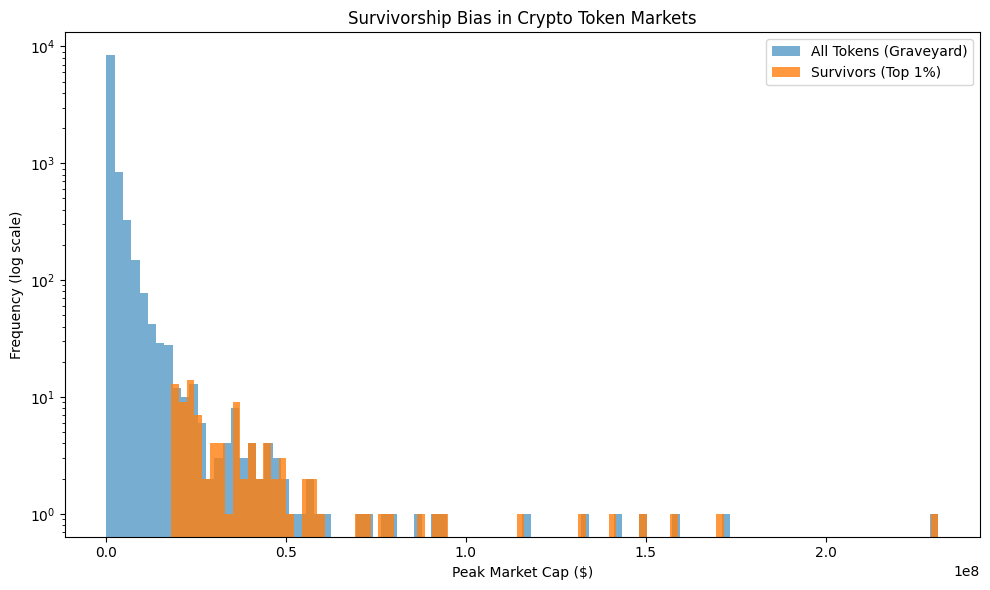

Mean Market Cap (All Tokens): $1,740,842.11
Mean Market Cap (Survivors Only): $43,633,521.22


In [26]:
# -----------------------------
# 1. Simulate token launches
# -----------------------------
np.random.seed(42)

n_tokens = 10_000

# Pareto distribution (heavy-tailed)
# alpha controls tail thickness (lower = fatter tail)
alpha = 1.5
raw_caps = np.random.pareto(alpha, n_tokens)

# Scale to something resembling market caps
market_caps = raw_caps * 1e6  # dollars

df_all = pd.DataFrame({
    "Peak_Market_Cap": market_caps
})

# -----------------------------
# 2. Survivors (Top 1%)
# -----------------------------
threshold = np.percentile(df_all["Peak_Market_Cap"], 99)
df_survivors = df_all[df_all["Peak_Market_Cap"] >= threshold]

# -----------------------------
# 3. Visualization
# -----------------------------
plt.figure(figsize=(10, 6))

plt.hist(
    df_all["Peak_Market_Cap"],
    bins=100,
    alpha=0.6,
    label="All Tokens (Graveyard)",
    log=True
)

plt.hist(
    df_survivors["Peak_Market_Cap"],
    bins=100,
    alpha=0.8,
    label="Survivors (Top 1%)",
    log=True
)

plt.xlabel("Peak Market Cap ($)")
plt.ylabel("Frequency (log scale)")
plt.title("Survivorship Bias in Crypto Token Markets")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4. Evaluate the bias
# -----------------------------
mean_all = df_all["Peak_Market_Cap"].mean()
mean_survivors = df_survivors["Peak_Market_Cap"].mean()

print(f"Mean Market Cap (All Tokens): ${mean_all:,.2f}")
print(f"Mean Market Cap (Survivors Only): ${mean_survivors:,.2f}")